# Understanding the NFL Spatiotemporal Model

This notebook walks through every part of the codebase in the order data flows through it. 

We'll trace one real play all the way from raw CSV to final embedding, looking at the actual numbers at each step.

**Order:**
1. The raw data — what does it actually look like?
2. Preprocessing — CSV → tensors
3. The model, layer by layer — what shape goes in, what comes out, why
4. The training objective — what does "learning" mean here?
5. The embeddings — what did we actually produce?
6. The key limitation — what does the model *can't* see?

In [4]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

DATA_PATH = '../data/week1.csv'

print('Setup complete')

Setup complete


---
## Part 1: The Raw Data

Before touching any model code, let's understand what we're working with.

In [5]:
df = pd.read_csv(DATA_PATH)

# Normalize column names
if "frameId" in df.columns:
    df = df.rename(columns={"frameId": "frame.id"})
if "playDirection" not in df.columns:
    df["playDirection"] = "right"

print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total rows: 986,022
Columns: ['time', 'x', 'y', 's', 'a', 'dis', 'o', 'dir', 'event', 'nflId', 'displayName', 'jerseyNumber', 'position', 'frame.id', 'team', 'gameId', 'playId', 'playDirection', 'route']


,time,x,y,s,a,dis,o,dir,event,nflId,displayName,jerseyNumber,position,frame.id,team,gameId,playId,playDirection,route
0,2018-09-07T01:07:14.599Z,91.73,26.67,0.00,0.01,0.02,289.57,240.93,NaN,310.0,Matt Ryan,2.0,QB,1,away,2018090600,75,left,NaN
1,2018-09-07T01:07:14.599Z,88.89,36.47,0.01,0.01,0.01,105.63,66.66,NaN,79848.0,Malcolm Jenkins,27.0,SS,1,home,2018090600,75,left,NaN
2,2018-09-07T01:07:14.599Z,91.35,44.16,0.02,0.03,0.01,290.45,16.86,NaN,2495454.0,Julio Jones,11.0,WR,1,away,2018090600,75,left,HITCH
3,2018-09-07T01:07:14.599Z,86.31,22.01,0.09,0.42,0.01,70.12,168.91,NaN,2495613.0,Corey Graham,24.0,FS,1,home,2018090600,75,left,NaN
4,2018-09-07T01:07:14.599Z,90.78,36.15,0.00,0.00,0.00,257.61,193.97,NaN,2533040.0,Mohamed Sanu,12.0,WR,1,away,2018090600,75,left,HITCH
5,2018-09-07T01:07:14.599Z,73.64,28.70,0.03,0.02,0.01,103.05,219.41,NaN,2534832.0,Rodney McLeod,23.0,FS,1,home,2018090600,75,left,NaN
6,2018-09-07T01:07:14.599Z,98.25,26.63,0.01,0.01,0.00,265.88,194.51,NaN,2543583.0,Devonta Freeman,24.0,RB,1,away,2018090600,75,left,NaN
7,2018-09-07T01:07:14.599Z,86.48,31.12,0.09,0.03,0.04,95.90,33.36,NaN,2552315.0,Jordan Hicks,58.0,MLB,1,home,2018090600,75,left,NaN
8,2018-09-07T01:07:14.599Z,82.67,20.53,0.03,0.07,0.01,81.14,174.57,NaN,2552689.0,Ronald Darby,21.0,CB,1,home,2018090600,75,left,NaN
9,2018-09-07T01:07:14.599Z,84.00,43.49,0.14,0.05,0.01,108.23,110.32,NaN,2555383.0,Jalen Mills,31.0,CB,1,home,2018090600,75,left,NaN


**Key insight:** Each row is *one player at one moment in time*.

- `frame.id` = the timestamp (10 frames/second in NFL tracking data)
- `nflId` = which player
- `x`, `y` = position on the field in yards
- `s` = speed in yards/second
- `dir` = direction the player is facing in degrees (0° = north, 90° = east)
- `playDirection` = which way the offense is going (left/right)

A single play might have 20+ players × 50+ frames = 1000+ rows.

In [7]:
# How many plays are there?
plays = df.groupby(["gameId", "playId"])
print(f"Number of plays: {len(plays)}")

# Detect frame column name
frame_col = "frameId" if "frameId" in df.columns else "frame.id"

# Pick one play to work with throughout this notebook
play_key = list(plays.groups.keys())[5]  # Play #5 — arbitrary choice
play_df = plays.get_group(play_key).sort_values(frame_col)

print(f"Working with play: gameId={play_key[0]}, playId={play_key[1]}")
print(f"Rows in this play: {len(play_df)}")
print(f"Frames: {play_df[frame_col].min()} to {play_df[frame_col].max()} ({play_df[frame_col].nunique()} total)")
print(f"Players: {play_df["nflId"].nunique()}")
print(f"Play direction: {play_df["playDirection"].iloc[0]}")

Number of plays: 1034
Working with play: gameId=2018090600, playId=320
Rows in this play: 765
Frames: 1 to 51 (51 total)
Players: 14
Play direction: right


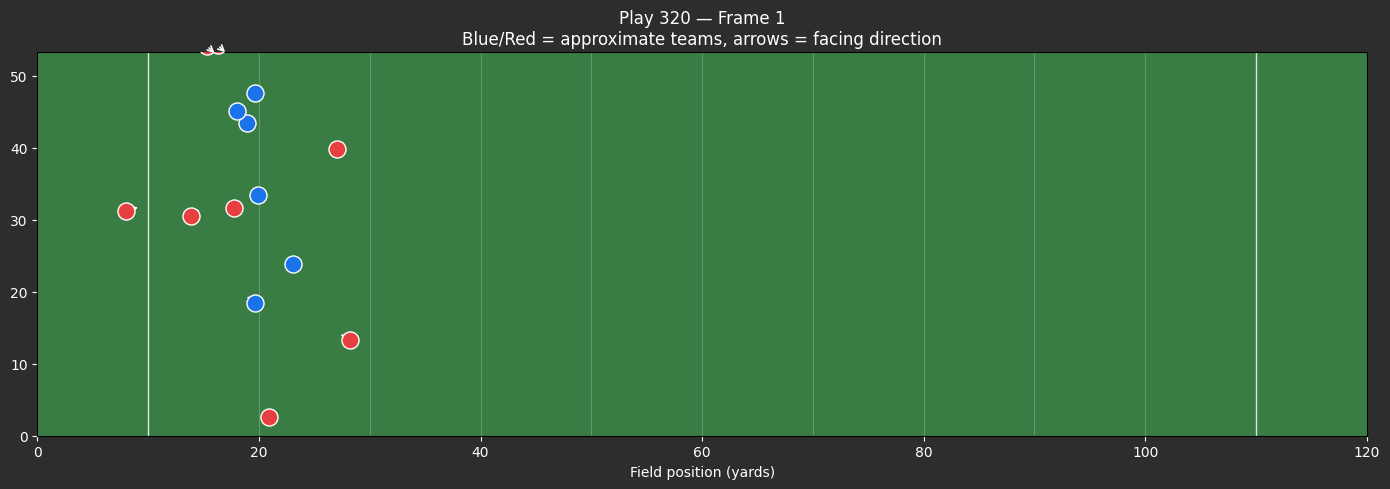

Each dot is a player. Arrows show which direction they face.
This is ONE frame. A full play has ~50 frames like this.


In [8]:
# Visualize player positions at frame 1 of this play
first_frame = play_df[play_df[frame_col] == play_df[frame_col].max()]

fig, ax = plt.subplots(figsize=(14, 5))

# Draw field
ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.set_facecolor('#3a7d44')
for x in range(10, 110, 10):
    ax.axvline(x, color='white', alpha=0.3, linewidth=0.5)
ax.axvline(10, color='white', alpha=0.8, linewidth=1)  # goal lines
ax.axvline(110, color='white', alpha=0.8, linewidth=1)

# Plot players
# Split by team using nflId (this is a rough approximation — real data has team column)
player_ids = first_frame['nflId'].values
mid = len(player_ids) // 2

for i, (_, row) in enumerate(first_frame.iterrows()):
    color = '#1a73e8' if i < mid else '#e84040'
    ax.scatter(row['x'], row['y'], s=150, c=color, zorder=5, edgecolors='white', linewidth=1)
    # Draw direction arrow
    angle_rad = np.radians(90 - row['dir'])  # convert to math convention
    dx = np.cos(angle_rad) * 1.5
    dy = np.sin(angle_rad) * 1.5
    ax.annotate('', xy=(row['x']+dx, row['y']+dy), xytext=(row['x'], row['y']),
                arrowprops=dict(arrowstyle='->', color='white', lw=1.2))

ax.set_xlabel('Field position (yards)', color='white')
ax.set_title(f'Play {play_key[1]} — Frame {play_df[frame_col].min()}\nBlue/Red = approximate teams, arrows = facing direction', 
             color='white')
ax.tick_params(colors='white')
fig.patch.set_facecolor('#2d2d2d')
plt.tight_layout()
plt.show()

print('Each dot is a player. Arrows show which direction they face.')
print('This is ONE frame. A full play has ~50 frames like this.')

---
## Part 2: Preprocessing — CSV to Tensors

The model can't work with DataFrames. It needs fixed-size rectangular arrays of numbers (tensors). This is the job of `preprocessing.py`.

### Step 2a: Normalize field direction

Half the plays go left, half go right. If we leave them as-is, the model has to learn the same play pattern twice (once going each direction). Instead we flip "left" plays so everything is left→right.

In [ ]:
from preprocessing import normalize_field_direction

print(f'Before normalization:')
print(f'  playDirection: {play_df["playDirection"].iloc[0]}')
print(f'  x range: {play_df["x"].min():.1f} to {play_df["x"].max():.1f}')

play_df_normalized = normalize_field_direction(play_df)

print(f'\nAfter normalization:')
print(f'  playDirection: {play_df_normalized["playDirection"].iloc[0]}')
print(f'  x range: {play_df_normalized["x"].min():.1f} to {play_df_normalized["x"].max():.1f}')

# Show what the flip does
if play_df['playDirection'].iloc[0] == 'left':
    print(f'\nPlay was going LEFT, so we flipped: x → 120 - x')
    sample_x_before = play_df['x'].iloc[0]
    sample_x_after = play_df_normalized['x'].iloc[0]
    print(f'  Example: x={sample_x_before:.1f} → x={sample_x_after:.1f}')
else:
    print(f'\nPlay was going RIGHT, so no flip needed — x values unchanged')

Before normalization:
  playDirection: right
  x range: 7.6 to 30.4

After normalization:
  playDirection: right
  x range: 7.6 to 30.4

Play was going RIGHT, so no flip needed — x values unchanged


### Step 2b: Converting to a (T, N, F) tensor

The preprocessing turns each play into a 3D array with shape `(T, N, F)` where:
- **T = 100**: time steps (frames). Fixed max.
- **N = 22**: players. Fixed max.
- **F = 4**: features per player (x, y, speed, direction)

Most plays have fewer than 100 frames and fewer than 22 players. The leftover slots are filled with zeros and tracked by a **mask**.

In [ ]:
from preprocessing import play_to_tensor

data, mask = play_to_tensor(play_df_normalized)

print(f'Output shapes:')
print(f'  data: {data.shape}  (T=100, N=22, F=4)')
print(f'  mask: {mask.shape}  (T=100, N=22)')

# How much of the tensor is actual data vs padding?
valid_entries = mask.sum()
total_entries = mask.size
print(f'\nMask stats:')
print(f'  Valid entries: {int(valid_entries)} ({100*valid_entries/total_entries:.1f}% of the tensor)')
print(f'  Padding zeros: {int(total_entries - valid_entries)} ({100*(1 - valid_entries/total_entries):.1f}% of the tensor)')

In [ ]:
# Look at what a single timestep looks like as raw numbers
print('data[0] = player features at frame 0:')
print('  Columns: [x, y, speed, direction]')
print()

df_frame0 = pd.DataFrame(
    data[0],
    columns=['x', 'y', 'speed', 'dir']
)
df_frame0['valid'] = mask[0].astype(bool)
print(df_frame0.to_string())
print()
print('Rows where valid=False are padding — zeros that the model should ignore')

In [ ]:
# Visualize the mask to understand the structure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Mask heatmap
ax1.imshow(mask.T, aspect='auto', cmap='Blues', origin='lower')
ax1.set_xlabel('Time step (frame)')
ax1.set_ylabel('Player slot (0-21)')
ax1.set_title('Mask: White = real data, Blue = padding zeros')
ax1.axvline(mask.sum(axis=1).argmin(), color='red', alpha=0.5, linestyle='--')

# How many players per frame
players_per_frame = mask.sum(axis=1)
ax2.plot(players_per_frame)
ax2.axhline(players_per_frame[players_per_frame > 0].mean(), color='red', linestyle='--', 
            label=f'mean = {players_per_frame[players_per_frame > 0].mean():.1f}')
ax2.set_xlabel('Time step (frame)')
ax2.set_ylabel('Number of valid players')
ax2.set_title('Players tracked per frame')
ax2.legend()

plt.tight_layout()
plt.show()

actual_frames = (players_per_frame > 0).sum()
print(f'This play has {actual_frames} real frames out of 100 max → {100-actual_frames} time steps are pure padding')

**Why use a fixed-size tensor instead of variable-length?**

GPU training works by processing a *batch* of plays simultaneously. Each play in the batch must be the same size so they can be stacked into one big array. The mask tells the model which values to compute on and which to skip — otherwise the zeros would corrupt the loss.

---
## Part 3: The Model, Layer by Layer

Now we trace a single play through `SpatiotemporalEncoder` step by step. 

The model takes `(B, T, N, F)` as input and produces `(B, embedding_dim)` as output. Let's follow one play (B=1) through each operation.

In [ ]:
# Set up: convert to tensors and add batch dimension
data_tensor = torch.FloatTensor(data).unsqueeze(0)   # (1, 100, 22, 4)
mask_tensor = torch.FloatTensor(mask).unsqueeze(0)   # (1, 100, 22)

print(f'Input shape: {data_tensor.shape}  (B=1, T=100, N=22, F=4)')
print(f'Mask shape:  {mask_tensor.shape}  (B=1, T=100, N=22)')

### Step 3a: Per-player MLP

**What:** A small neural network applied to every player at every timestep *independently*.

**Why:** We want to learn a richer representation of each player's state. Instead of raw `[x, y, speed, dir]` (4 numbers), we want a learned 32-dim feature vector that captures combinations like "fast player moving towards the line of scrimmage."

**How:** Reshape the tensor to treat every `(player, timestep)` pair as an independent sample, run the MLP, reshape back.

In [ ]:
# Replicate what happens in model.py
input_dim = 4
player_hidden_dim = 32

player_encoder = nn.Sequential(
    nn.Linear(input_dim, player_hidden_dim),
    nn.ReLU(),
    nn.Linear(player_hidden_dim, player_hidden_dim),
    nn.ReLU()
)

B, T, N, F = data_tensor.shape
print(f'B={B}, T={T}, N={N}, F={F}')

# Step 1: Flatten to process all players at once
data_flat = data_tensor.reshape(B * T * N, F)  # Treat every player-timestep as one sample
print(f'\nAfter reshape: {data_flat.shape}')
print(f'({B}×{T}×{N} = {B*T*N} individual player-frame observations, each with {F} features)')

# Step 2: Run MLP
with torch.no_grad():
    player_features_flat = player_encoder(data_flat)  # (B*T*N, 32)
print(f'\nAfter MLP: {player_features_flat.shape}  (each player now has 32-dim features)')

# Step 3: Reshape back
player_features = player_features_flat.reshape(B, T, N, player_hidden_dim)
print(f'After reshape back: {player_features.shape}')

In [ ]:
# Examine what the MLP actually does to the numbers
print('Before MLP — raw features for first player, first frame:')
print(f'  [x, y, speed, dir] = {data_tensor[0, 0, 0].numpy()}')

print(f'\nAfter MLP — learned features for same player:')
print(f'  {player_features[0, 0, 0].detach().numpy()}')
print(f'\n(These are random since we haven\'t trained — after training these 32 numbers')
print(f'would encode meaningful combinations of speed/direction/position)')

**Important:** The MLP has the same weights for all players. Player 0 and player 21 go through *exactly the same network*. This is intentional — we want the model to learn general player behavior, not player-specific behavior.

This is called **weight sharing** — similar to how a CNN uses the same filter across all image patches.

### Step 3b: Player Pooling (Masked Mean)

**What:** Collapse the 22-player dimension into a single vector per timestep.

**Why:** The LSTM needs a single vector per timestep, not 22 vectors. We need to aggregate the players.

**How:** Compute the mean across valid players (mask out padding zeros first).

In [ ]:
# Masked mean pooling across players
mask_expanded = mask_tensor.unsqueeze(-1)  # (B, T, N, 1) — add feature dim for broadcasting

# Zero out features from padding players
masked_features = player_features * mask_expanded  # (B, T, N, 32) — padding players = 0 vector

# Sum across players, divide by how many real players there are
player_sum = masked_features.sum(dim=2)  # (B, T, 32) — sum over N dimension
player_count = mask_tensor.sum(dim=2, keepdim=True).clamp(min=1)  # (B, T, 1) — count valid
timestep_features = player_sum / player_count  # (B, T, 32) — mean over real players

print(f'After player pooling: {timestep_features.shape}')
print(f'We collapsed N=22 players → 1 vector per timestep')
print(f'Each of the {T} timesteps now has a 32-dim summary of all players')

In [ ]:
# Visualize what the mean pooling discards
print('THE KEY LIMITATION OF MEAN POOLING:')
print('='*50)
print()
print('Imagine frame 10 with these players:')
print('  QB: x=32, y=27, speed=2.1, dir=90   (dropping back)')
print('  WR: x=28, y=15, speed=8.4, dir=0    (running deep route)')
print('  CB: x=27, y=14, speed=8.3, dir=0    (covering the WR)')
print('  ...18 more players')
print()
print('After mean pooling, timestep 10 becomes:')
print('  [avg_x, avg_y, avg_speed, avg_dir, ...] -- 32 numbers')
print()
print('LOST INFORMATION:')
print('  - The WR and CB are right next to each other (coverage matchup)')
print('  - Who is fast vs slow')
print('  - Which players are moving in the same direction')
print('  - Spatial relationships between specific players')
print()
print('This is exactly what attention will fix. Instead of treating all')
print('22 players equally, attention learns to ask: "which player combinations')
print('matter most for understanding this play?"')

### Step 3c: LSTM — Temporal Encoding

**What:** Process the sequence of 100 timestep vectors and produce a new vector at each step that "remembers" what came before.

**Why:** The mean pooling step lost all temporal information — each timestep is independent. The LSTM restores temporal context by maintaining a hidden state that evolves over time.

**How:** At each timestep `t`, the LSTM combines the new input with its hidden state `h_{t-1}` from the previous step.

In [ ]:
lstm_hidden_dim = 64

lstm = nn.LSTM(
    input_size=player_hidden_dim,   # 32 — our aggregated player features
    hidden_size=lstm_hidden_dim,    # 64 — the hidden state dimension
    num_layers=1,
    batch_first=True
)

with torch.no_grad():
    lstm_out, (h_n, c_n) = lstm(timestep_features)

print(f'Input to LSTM:  {timestep_features.shape}  (B, T=100, 32)')
print(f'Output:         {lstm_out.shape}  (B, T=100, 64)')
print(f'Final hidden h: {h_n.shape}  (num_layers=1, B, 64)')
print(f'Final cell c:   {c_n.shape}  (num_layers=1, B, 64)')
print()
print('lstm_out[t] is a 64-dim vector summarizing everything up to timestep t')
print('It\'s different from timestep_features[t] because it incorporates history')

In [ ]:
# Show how LSTM output changes as it processes the sequence
# Plot the L2 norm of the hidden state over time
lstm_norms = lstm_out[0].detach().norm(dim=-1).numpy()  # (T,)
time_valid = mask_tensor[0].sum(dim=-1).numpy()  # (T,) — players per frame

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(lstm_norms)
ax1.set_ylabel('||h_t||  (hidden state norm)')
ax1.set_title('LSTM Hidden State Evolution Over Time')
ax1.axvspan(time_valid.sum(), 100, alpha=0.15, color='red', label='padding region')
ax1.legend()

ax2.plot(time_valid)
ax2.set_ylabel('Players per frame')
ax2.set_xlabel('Time step')
ax2.axvspan(time_valid.sum(), 100, alpha=0.15, color='red')

plt.tight_layout()
plt.show()

print('Notice: the hidden state still evolves during padding frames (red region)')
print('It\'s processing zeros and accumulating garbage — this is a known weakness')
print('The masked mean pooling in the next step partially compensates for this')

### Step 3d: Temporal Pooling + Projection

**What:** Collapse the T=100 time dimension into a single vector, then project to the final embedding size.

**Why:** We need a *single* fixed-size vector to represent the whole play. Same masked mean as before, but over time now.

In [ ]:
embedding_dim = 128
projection = nn.Linear(lstm_hidden_dim, embedding_dim)

# Build time-level mask: timestep is valid if it has at least 1 real player
time_mask = (mask_tensor.sum(dim=2) > 0).float()  # (B, T)
time_mask_expanded = time_mask.unsqueeze(-1)        # (B, T, 1)

# Masked mean over time
masked_lstm = lstm_out * time_mask_expanded   # (B, T, 64) — zero out padding timesteps
lstm_sum = masked_lstm.sum(dim=1)             # (B, 64) — sum over T
time_count = time_mask.sum(dim=1, keepdim=True).clamp(min=1)  # (B, 1)
play_features = lstm_sum / time_count         # (B, 64)

print(f'After temporal pooling: {play_features.shape}  (collapsed T=100 → 1 vector)')

with torch.no_grad():
    embedding = projection(play_features)  # (B, 128)

print(f'After projection:       {embedding.shape}  (final embedding)')
print(f'\nThis 128-dim vector is the "fingerprint" of the entire play')
print(f'Values: {embedding[0].detach().numpy()[:10]} ...')

### Full forward pass — putting it all together

Now let's run the actual model to confirm we replicated it correctly:

In [ ]:
from model import SpatiotemporalEncoder, PlayAutoencoder

# Run the full model
encoder = SpatiotemporalEncoder()
encoder.eval()

with torch.no_grad():
    embedding_full = encoder(data_tensor, mask_tensor)

print(f'Full encoder output: {embedding_full.shape}')
print(f'Shape summary of the whole pipeline:')
print(f'  Input:             (1, 100, 22, 4)  — play')
print(f'  After player MLP:  (1, 100, 22, 32) — richer per-player features')
print(f'  After player pool: (1, 100, 32)     — one vector per timestep')
print(f'  After LSTM:        (1, 100, 64)     — time-aware vectors')
print(f'  After time pool:   (1, 64)          — one vector per play')
print(f'  After projection:  (1, 128)         — final embedding')

---
## Part 4: The Training Objective — What Does the Model Actually Learn?

We have a model that maps plays to 128-dim vectors. But what makes it learn *useful* embeddings?

The answer: **autoencoder training**. We add a decoder that tries to reconstruct the original play from the embedding. The model is forced to pack everything important about the play into those 128 numbers.

In [ ]:
# Show the decoder architecture
autoencoder = PlayAutoencoder()

print('Decoder architecture:')
print(autoencoder.decoder)
print()

output_size = 100 * 22 * 4
print(f'Output size: T×N×F = 100×22×4 = {output_size} numbers')
print(f'It must reconstruct ALL player positions across ALL frames from 128 numbers')
print(f'Compression ratio: {output_size / 128:.0f}:1')

In [ ]:
# Run the full autoencoder
autoencoder.eval()
with torch.no_grad():
    reconstruction, embedding = autoencoder(data_tensor, mask_tensor)

print(f'Input shape:          {data_tensor.shape}')
print(f'Embedding shape:      {embedding.shape}  ← the compressed representation')
print(f'Reconstruction shape: {reconstruction.shape}  ← attempt to rebuild the input')

### The Loss Function: Masked MSE

We measure how well the decoder reconstructed the input. We only compute the error on *real* player positions (mask=1), not on padding.

In [ ]:
from train import masked_mse_loss

# Compute loss on untrained model
loss = masked_mse_loss(reconstruction, data_tensor, mask_tensor)
print(f'Loss on untrained model: {loss.item():.4f}')
print(f'(This is MSE — mean squared error on each of the 4 features)')
print(f'After training, this goes down as the model gets better at reconstruction')

# Show what the loss is measuring
print(f'\nHow the loss is computed:')
mask_exp = mask_tensor.unsqueeze(-1)   # (1, 100, 22, 1)
squared_error = (reconstruction - data_tensor) ** 2  # (1, 100, 22, 4)
masked_error = squared_error * mask_exp               # zero out padding
manual_loss = masked_error.sum() / mask_exp.sum()
print(f'  Manual computation: {manual_loss.item():.4f}  (should match above)')

In [ ]:
# Load the trained model and compare
checkpoint = torch.load('../models/best_model.pt', map_location='cpu')
trained_autoencoder = PlayAutoencoder()
trained_autoencoder.load_state_dict(checkpoint['model_state_dict'])
trained_autoencoder.eval()

with torch.no_grad():
    trained_reconstruction, trained_embedding = trained_autoencoder(data_tensor, mask_tensor)
    trained_loss = masked_mse_loss(trained_reconstruction, data_tensor, mask_tensor)

print(f'Loss: untrained={loss.item():.4f}  vs  trained={trained_loss.item():.4f}')
print(f'Trained at epoch {checkpoint["epoch"]}, best val loss: {checkpoint["val_loss"]:.4f}')

In [ ]:
# Compare original vs reconstructed positions for one player over time
original_xy = data_tensor[0, :, 0, :2].numpy()           # player 0, x and y
reconstructed_xy = trained_reconstruction[0, :, 0, :2].detach().numpy()
valid_frames = mask_tensor[0, :, 0].numpy().astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature, label in zip(axes, [0, 1], ['x (field length)', 'y (field width)']):
    orig = original_xy[:, feature][valid_frames]
    recon = reconstructed_xy[:, feature][valid_frames]
    frames = np.where(valid_frames)[0]
    
    ax.plot(frames, orig, label='Original', linewidth=2)
    ax.plot(frames, recon, label='Reconstructed', linestyle='--', linewidth=2)
    ax.fill_between(frames, orig, recon, alpha=0.2, color='red', label='Error')
    ax.set_xlabel('Frame')
    ax.set_ylabel(label)
    ax.set_title(f'Player 0 — {label}')
    ax.legend()

plt.suptitle('Original vs Reconstructed Player Trajectory', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 5: The Embeddings — What Did We Actually Produce?

We have 177 plays, each compressed to a 128-dim vector. Let's look at whether these vectors capture real structure.

In [ ]:
# Load pre-computed embeddings
emb_data = np.load('../embeddings.npz', allow_pickle=True)
embeddings = emb_data['embeddings']    # (177, 128)
play_ids = emb_data['play_ids']        # list of (gameId, playId) tuples

print(f'Embeddings shape: {embeddings.shape}')
print(f'Each row is a 128-dim vector representing one play')

In [ ]:
# t-SNE: reduce 128 dimensions to 2 so we can plot them
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Normalize embeddings first
embeddings_norm = StandardScaler().fit_transform(embeddings)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=20, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_norm)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     alpha=0.7, s=60, c=range(len(embeddings_2d)), cmap='viridis')
plt.colorbar(scatter, ax=ax, label='Play index (chronological order)')
ax.set_title('t-SNE projection of 177 play embeddings\n(Similar plays should cluster together)', 
             fontsize=12)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

print('If there are visible clusters, the model learned to distinguish different play types')
print('Color = order in the game (early plays = purple, late plays = yellow)')

In [ ]:
# Similarity: find the most and least similar play pairs
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)  # (177, 177)

# Mask out diagonal (self-similarity)
np.fill_diagonal(sim_matrix, -1)

# Most similar pair
max_idx = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
min_idx = np.unravel_index(sim_matrix.argmin(), sim_matrix.shape)

print(f'Most similar pair:')
print(f'  Play {max_idx[0]} (ID: {play_ids[max_idx[0]]}) ↔ Play {max_idx[1]} (ID: {play_ids[max_idx[1]]})')
print(f'  Cosine similarity: {sim_matrix[max_idx]:.4f}')

print(f'\nLeast similar pair:')
print(f'  Play {min_idx[0]} (ID: {play_ids[min_idx[0]]}) ↔ Play {min_idx[1]} (ID: {play_ids[min_idx[1]]})')
print(f'  Cosine similarity: {sim_matrix[min_idx]:.4f}')

# Distribution of similarities
np.fill_diagonal(sim_matrix, 0)  # restore
upper_tri = sim_matrix[np.triu_indices(177, k=1)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(upper_tri, bins=40, edgecolor='black', alpha=0.7)
ax.axvline(upper_tri.mean(), color='red', linestyle='--', label=f'mean = {upper_tri.mean():.3f}')
ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Number of play pairs')
ax.set_title('Distribution of pairwise play similarities')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 6: Summary and What's Next

Here's the full picture of what you built and where the model's limits are:

In [ ]:
print('WHAT YOU BUILT')
print('='*60)
print()
print('A self-supervised encoder that compresses NFL plays into')
print('128-dim vectors using:')
print()
print('  1. Per-player MLP  (4 → 32 dims per player)')
print('     Learns richer feature combinations per player')
print()
print('  2. Masked mean pool over players  (22 → 1 per timestep)')
print('     Aggregates all players into one timestep summary')
print('     ⚠ LOSES: spatial relationships between specific players')
print()
print('  3. LSTM  (T=100 sequence → T=100 history-aware vectors)')
print('     Captures temporal patterns (how play develops)')
print('     ⚠ LOSES: long-range dependencies (can\'t look ahead)')
print()
print('  4. Masked mean pool over time  (100 → 1)')
print('     Final play-level summary')
print('     ⚠ LOSES: when in the play things happened')
print()
print('  5. Linear projection  (64 → 128)')
print('     Maps to final embedding space')
print()
print('WHAT\'S NEXT: THE TRANSFORMER FIX')
print('='*60)
print()
print('The two mean pooling steps are the biggest weaknesses.')
print('Transformers fix both:')
print()
print('  Player mean pool → Multi-head self-attention over players')
print('  "Which players are most relevant to each other?"')
print('  e.g., WR-CB pairs, QB-pass-rusher matchups')
print()
print('  Temporal mean pool → Temporal self-attention')
print('  "Which timesteps are most informative for understanding this play?"')
print('  e.g., the snap, the route break, the throw')

In [ ]:
# Count parameters to understand model size
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

ae = PlayAutoencoder()
total = count_params(ae)
encoder_params = count_params(ae.encoder)
decoder_params = count_params(ae.decoder)

print(f'Model parameter breakdown:')
print(f'  Player MLP:        {count_params(ae.encoder.player_encoder):>8,}')
print(f'  LSTM:              {count_params(ae.encoder.lstm):>8,}')
print(f'  Projection:        {count_params(ae.encoder.projection):>8,}')
print(f'  ─────────────────────────')
print(f'  Total encoder:     {encoder_params:>8,}')
print(f'  Total decoder:     {decoder_params:>8,}')
print(f'  ─────────────────────────')
print(f'  Grand total:       {total:>8,}')
print()
print(f'The decoder is {decoder_params/total*100:.0f}% of the parameters')
print(f'but is thrown away at inference — only the encoder matters')